# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Prima Surya Nusantara| 5054251036|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("diabetes.csv")

print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

print("\nLima baris pertama:")
display(df.head())

print("\nInformasi tipe data:")
df.info()

print("\nStatistik deskriptif:")
display(df.describe(include="all").T)

print("\nJumlah missing value per kolom:")
display(df.isna().sum().to_frame("Jumlah Missing"))

kolom_cek_nol = [
    kolom for kolom in [
        "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"
    ]
    if kolom in df.columns
]

print("\nJumlah nilai nol pada kolom yang perlu diperiksa:")
display(df[kolom_cek_nol].eq(0).sum().to_frame("Jumlah Nol"))

Jumlah baris: 768
Jumlah kolom: 9

Lima baris pertama:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1



Informasi tipe data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB

Statistik deskriptif:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00



Jumlah missing value per kolom:


,Jumlah Missing
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



Jumlah nilai nol pada kolom yang perlu diperiksa:


,Jumlah Nol
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


,Jumlah,Persentase (%)
Outcome,,
0,500,65.1
1,268,34.9


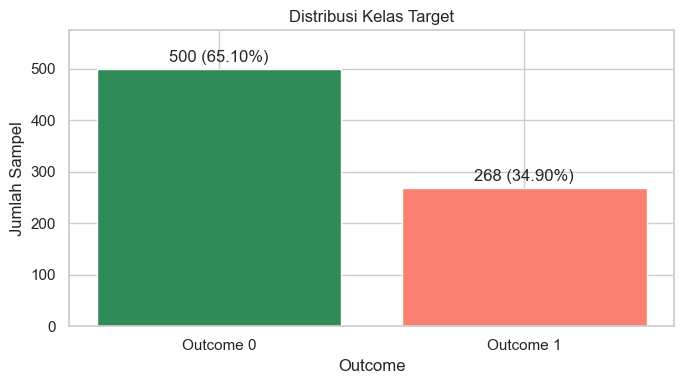

In [3]:
jumlah_kelas = (
    df["Outcome"].value_counts()
    .reindex([0, 1], fill_value=0)
)
persentase = jumlah_kelas / jumlah_kelas.sum() * 100

display(pd.DataFrame({
    "Jumlah": jumlah_kelas,
    "Persentase (%)": persentase.round(2)
}).rename_axis("Outcome"))

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    ["Outcome 0", "Outcome 1"],
    jumlah_kelas.values,
    color=["seagreen", "salmon"]
)

ax.bar_label(
    bars,
    labels=[
        f"{jumlah} ({persen:.2f}%)"
        for jumlah, persen in zip(jumlah_kelas, persentase)
    ],
    padding=3
)

ax.set_title("Distribusi Kelas Target")
ax.set_xlabel("Outcome")
ax.set_ylabel("Jumlah Sampel")
ax.set_ylim(0, jumlah_kelas.max() * 1.15)

plt.tight_layout()
plt.show()

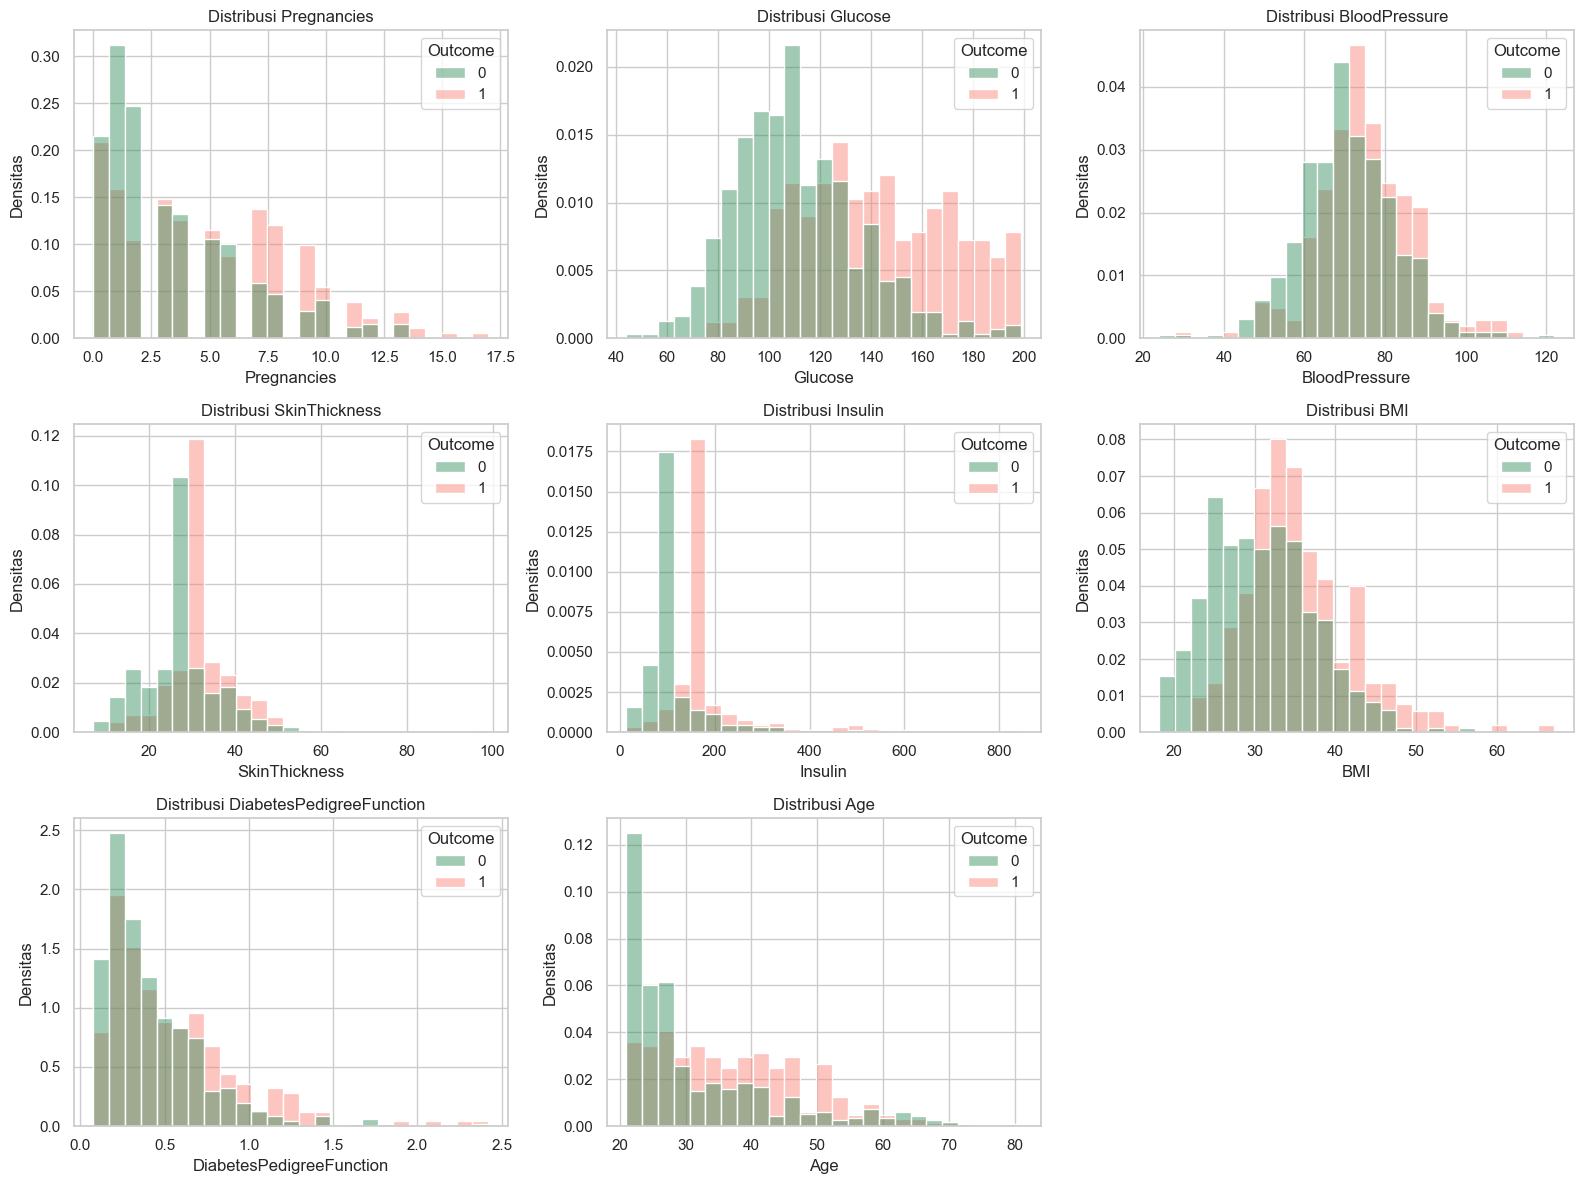

In [4]:
fitur_numerik = (
    df.drop(columns="Outcome")
    .select_dtypes(include=np.number)
    .columns.tolist()
)

jumlah_kolom = 3
jumlah_baris = int(np.ceil(len(fitur_numerik) / jumlah_kolom))

fig, axes = plt.subplots(
    jumlah_baris,
    jumlah_kolom,
    figsize=(16, 4 * jumlah_baris),
    squeeze=False
)

for ax, fitur in zip(axes.flat, fitur_numerik):
    sns.histplot(
        data=df,
        x=fitur,
        hue="Outcome",
        hue_order=[0, 1],
        bins=25,
        stat="density",
        common_norm=False,
        multiple="layer",
        alpha=0.45,
        palette={0: "seagreen", 1: "salmon"},
        ax=ax
    )

    ax.set_title(f"Distribusi {fitur}")
    ax.set_ylabel("Densitas")

for ax in list(axes.flat)[len(fitur_numerik):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

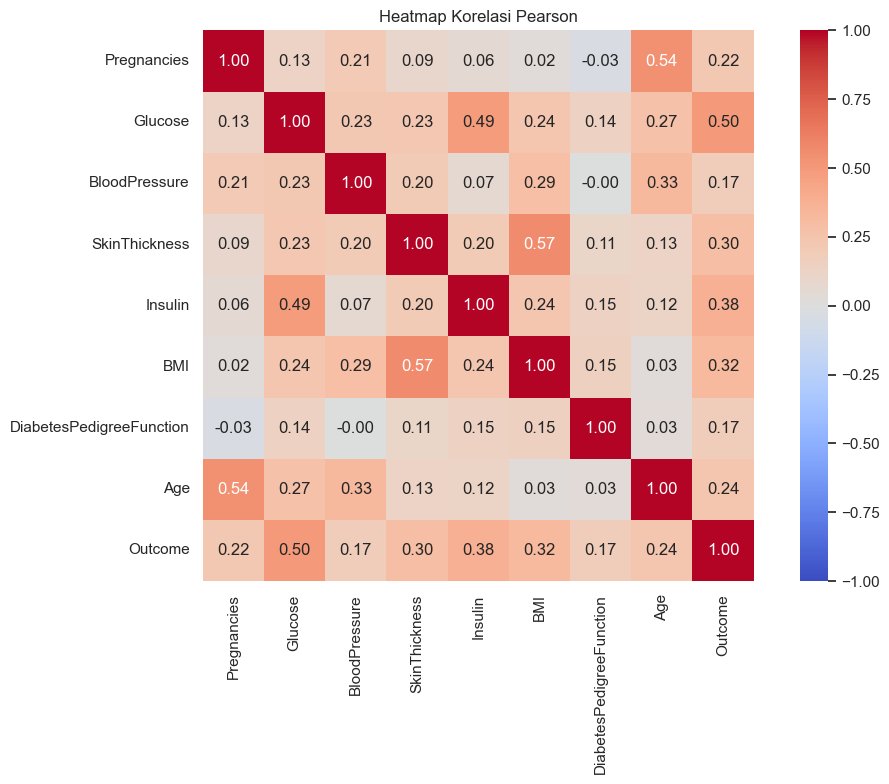

Korelasi fitur dengan Outcome:


,Korelasi
Glucose,0.495990
Insulin,0.377081
BMI,0.315577
SkinThickness,0.295138
Age,0.238356
Pregnancies,0.221898
BloodPressure,0.174469
DiabetesPedigreeFunction,0.173844


In [ ]:
korelasi = df[fitur_numerik + ["Outcome"]].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    korelasi,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True
)

plt.title("Heatmap Korelasi Pearson")
plt.tight_layout()
plt.show()

korelasi_target = (
    korelasi["Outcome"]
    .drop("Outcome")
    .sort_values(key=lambda nilai: nilai.abs(), ascending=False)
)

print("Korelasi fitur dengan Outcome:")
display(korelasi_target.to_frame("Korelasi"))

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [6]:
kolom_nol = [
    "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"
]

jumlah_nol = df[kolom_nol].eq(0).sum()

display(pd.DataFrame({
    "Jumlah Nol": jumlah_nol,
    "Persentase (%)": (jumlah_nol / len(df) * 100).round(2)
}))

,Jumlah Nol,Persentase (%)
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0


In [ ]:
df_preprocessing = df.copy()

df_preprocessing[kolom_nol] = (
    df_preprocessing[kolom_nol].replace(0, np.nan)
)

print("Missing value setelah penggantian nilai nol:")
display(df_preprocessing.isna().sum().to_frame("Jumlah Missing"))

imputer = SimpleImputer(strategy="median")

Missing value setelah penggantian nilai nol:


,Jumlah Missing
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
X = df_preprocessing.drop(columns="Outcome")
y = df_preprocessing["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Ukuran train:", X_train_imputed.shape)
print("Ukuran test :", X_test_imputed.shape)

print("\nMedian dari train set:")
display(pd.Series(
    imputer.statistics_,
    index=X_train.columns,
    name="Median"
))

print("\nMissing train:", X_train_imputed.isna().sum().sum())
print("Missing test :", X_test_imputed.isna().sum().sum())

print("\nDistribusi kelas (%):")
display(pd.DataFrame({
    "Train": y_train.value_counts(normalize=True).mul(100),
    "Test": y_test.value_counts(normalize=True).mul(100)
}).round(2))

Ukuran train: (614, 8)
Ukuran test : (154, 8)

Median dari train set:


Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
SkinThickness                28.0000
Insulin                     102.5000
BMI                          32.4000
DiabetesPedigreeFunction      0.3825
Age                          29.0000
Name: Median, dtype: float64


Missing train: 0
Missing test : 0

Distribusi kelas (%):


,Train,Test
Outcome,,
0,65.15,64.94
1,34.85,35.06


In [ ]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed),
    columns=X_train_imputed.columns,
    index=X_train_imputed.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),
    columns=X_test_imputed.columns,
    index=X_test_imputed.index
)

print("Lima baris pertama train setelah scaling:")
display(X_train_scaled.head())

print("Ukuran train:", X_train_scaled.shape)
print("Ukuran test :", X_test_scaled.shape)

Lima baris pertama train setelah scaling:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,-0.851355,-1.056869,-0.826687,-1.895290,-1.170378,-0.766150,0.310794,-0.792169
711,0.356576,0.142855,0.477009,-0.224736,-1.427642,-0.414448,-0.116439,0.561034
373,-0.549372,-0.556984,-1.152611,1.223078,-0.545594,0.362227,-0.764862,-0.707594
46,-0.851355,0.809369,-1.315573,-0.224736,-0.441463,-0.399794,0.262314,-0.369293
682,-1.153338,-0.890241,-0.663725,1.111708,-0.410836,1.783690,-0.337630,-0.961320


Ukuran train: (614, 8)
Ukuran test : (154, 8)


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [11]:
from sklearn.naive_bayes import GaussianNB

model_gaussian_nb = GaussianNB()
model_gaussian_nb.fit(X_train_scaled, y_train)

print("Model GaussianNB berhasil dilatih.")

Model GaussianNB berhasil dilatih.


In [ ]:
y_pred_gaussian_nb = model_gaussian_nb.predict(X_test_scaled)

indeks_kelas_1 = np.where(model_gaussian_nb.classes_ == 1)[0][0]
y_proba_gaussian_nb = model_gaussian_nb.predict_proba(
    X_test_scaled
)[:, indeks_kelas_1]

print("Prediksi 5 label pertama:", y_pred_gaussian_nb[:5])
print("Probabilitas kelas 1:", y_proba_gaussian_nb[:5])

Prediksi 5 label pertama: [0 0 0 0 0]
Probabilitas kelas 1: [0.39463909 0.21090162 0.23283517 0.18530596 0.00605332]


## 3.2 Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression

model_logistic_regression = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_logistic_regression.fit(X_train_scaled, y_train)

print("Model Logistic Regression berhasil dilatih.")

Model Logistic Regression berhasil dilatih.


In [14]:
y_pred_logistic_regression = model_logistic_regression.predict(
    X_test_scaled
)

indeks_kelas_1 = np.where(
    model_logistic_regression.classes_ == 1
)[0][0]

y_proba_logistic_regression = model_logistic_regression.predict_proba(
    X_test_scaled
)[:, indeks_kelas_1]

print("Prediksi 5 label pertama:", y_pred_logistic_regression[:5])
print("Probabilitas kelas 1:", y_proba_logistic_regression[:5])

Prediksi 5 label pertama: [0 0 0 0 0]
Probabilitas kelas 1: [0.47739551 0.07407477 0.37011559 0.33773074 0.03196289]


# 4. Evaluasi Model

In [15]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, roc_auc_score
)

prediksi_model = {
    "GaussianNB": y_pred_gaussian_nb,
    "Logistic Regression": y_pred_logistic_regression
}

hasil_evaluasi = []

for nama, prediksi in prediksi_model.items():
    hasil_evaluasi.append({
        "Model": nama,
        "Accuracy": accuracy_score(y_test, prediksi),
        "Precision": precision_score(
            y_test, prediksi, pos_label=1, zero_division=0
        ),
        "Recall": recall_score(
            y_test, prediksi, pos_label=1, zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, prediksi, pos_label=1, zero_division=0
        )
    })

tabel_evaluasi = pd.DataFrame(hasil_evaluasi).set_index("Model")
display(tabel_evaluasi.round(4))

,Accuracy,Precision,Recall,F1-Score
Model,,,,
GaussianNB,0.7273,0.6034,0.6481,0.6250
Logistic Regression,0.7078,0.5882,0.5556,0.5714


GaussianNB: TN=77, FP=23, FN=19, TP=35
Logistic Regression: TN=79, FP=21, FN=24, TP=30


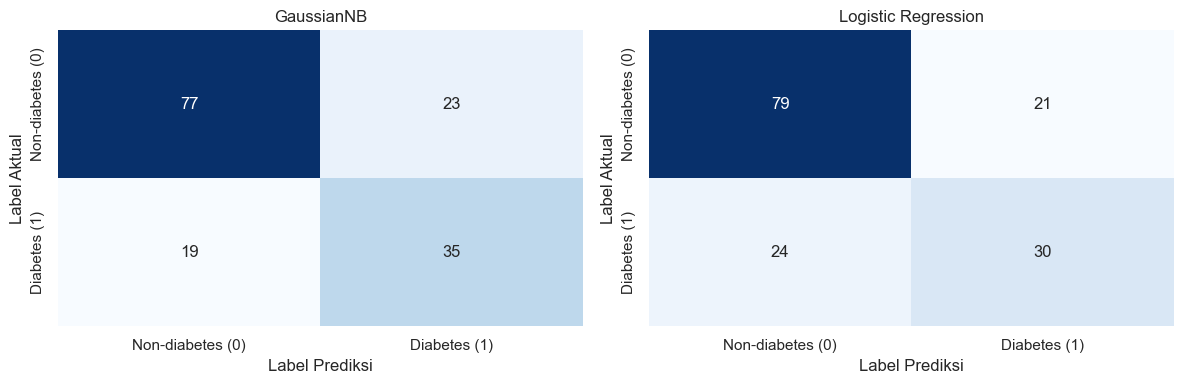

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (nama, prediksi) in zip(axes, prediksi_model.items()):
    cm = confusion_matrix(y_test, prediksi, labels=[0, 1])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Non-diabetes (0)", "Diabetes (1)"],
        yticklabels=["Non-diabetes (0)", "Diabetes (1)"],
        ax=ax
    )

    ax.set_title(nama)
    ax.set_xlabel("Label Prediksi")
    ax.set_ylabel("Label Aktual")

    tn, fp, fn, tp = cm.ravel()
    print(f"{nama}: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

plt.tight_layout()
plt.show()

AUC GaussianNB: 0.801667
AUC Logistic Regression: 0.826296


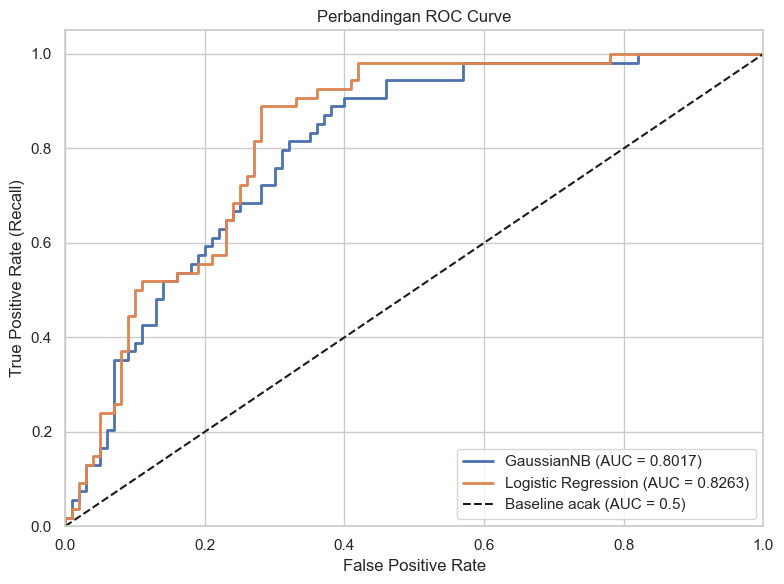

In [17]:
probabilitas_model = {
    "GaussianNB": y_proba_gaussian_nb,
    "Logistic Regression": y_proba_logistic_regression
}

fig, ax = plt.subplots(figsize=(8, 6))

for nama, probabilitas in probabilitas_model.items():
    fpr, tpr, _ = roc_curve(y_test, probabilitas, pos_label=1)
    auc = roc_auc_score(y_test, probabilitas)

    ax.plot(
        fpr, tpr,
        linewidth=2,
        label=f"{nama} (AUC = {auc:.4f})"
    )
    print(f"AUC {nama}: {auc:.6f}")

ax.plot(
    [0, 1], [0, 1],
    "k--",
    label="Baseline acak (AUC = 0.5)"
)

ax.set_title("Perbandingan ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

,Koefisien
BloodPressure,-0.004245
Age,0.159826
DiabetesPedigreeFunction,0.174725
SkinThickness,0.294976
Pregnancies,0.337228
BMI,0.466051
Insulin,0.614170
Glucose,0.934942


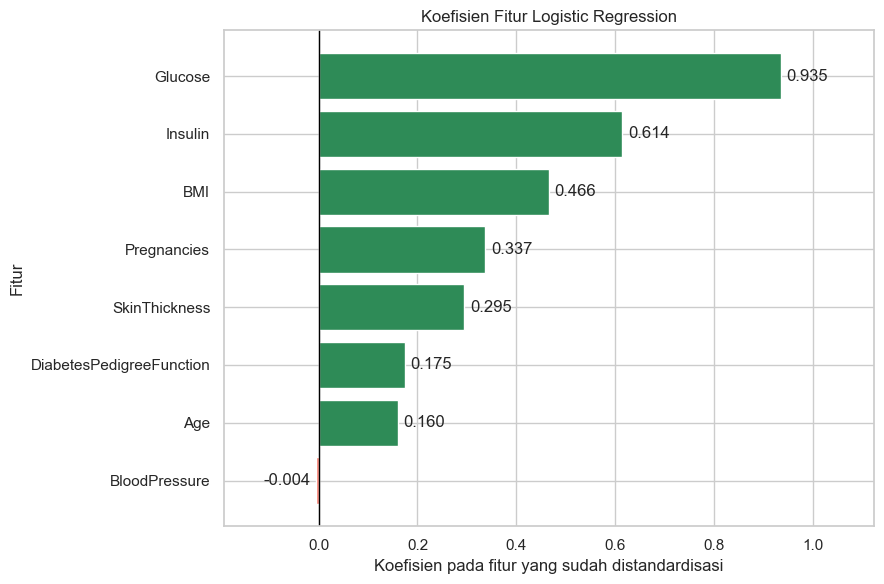

In [18]:
koefisien = pd.Series(
    model_logistic_regression.coef_[0],
    index=X_train_scaled.columns,
    name="Koefisien"
).sort_values()

display(koefisien.to_frame())

warna = [
    "seagreen" if nilai >= 0 else "salmon"
    for nilai in koefisien
]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    koefisien.index,
    koefisien.values,
    color=warna
)

ax.bar_label(bars, fmt="%.3f", padding=4)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Koefisien Fitur Logistic Regression")
ax.set_xlabel("Koefisien pada fitur yang sudah distandardisasi")
ax.set_ylabel("Fitur")
ax.margins(x=0.2)

plt.tight_layout()
plt.show()

# 5. Analisis

## 5.1. Perbandingan Metrik Evaluasi
Eksperimen membandingkan Gaussian Naive Bayes dan Logistic Regression menggunakan pembagian data train-test sebesar 80:20 dengan stratifikasi kelas. Nilai nol pada fitur tertentu ditangani dengan imputasi median, kemudian fitur distandardisasi menggunakan StandardScaler. Median dan parameter standardisasi dipelajari hanya dari data train untuk mencegah data leakage.

Data test terdiri dari 154 sampel, yaitu 100 sampel non-diabetes dan 54 sampel diabetes. Kedua model dievaluasi menggunakan data test yang sama.
| Model               | Accuracy | Precision | Recall | F1-Score |      AUC |
| ------------------- | -------: | --------: | -----: | -------: | -------: |
| GaussianNB          |   72,73% |    60,34% | 64,81% |   62,50% | 0,801667 |
| Logistic Regression |   70,78% |    58,82% | 55,56% |   57,14% | 0,826296 |

GaussianNB menghasilkan Accuracy, Precision, Recall, dan F1-Score lebih tinggi daripada Logistic Regression. GaussianNB mengklasifikasikan 112 sampel dengan benar, sedangkan Logistic Regression mengklasifikasikan 109 sampel dengan benar. Selisih akurasinya sekitar 1,95 poin persentase, atau tiga sampel.

Precision GaussianNB sebesar 60,34% berarti sekitar 60 dari setiap 100 prediksi diabetes sesuai dengan label aktual. Logistic Regression memperoleh precision sedikit lebih rendah, yaitu 58,82%.

Perbedaan lebih besar terlihat pada recall. GaussianNB berhasil mendeteksi 64,81% sampel diabetes, sedangkan Logistic Regression mendeteksi 55,56%. Selisih sekitar 9,26 poin persentase menunjukkan bahwa GaussianNB lebih banyak menemukan sampel diabetes pada aturan keputusan bawaan.

F1-Score GaussianNB sebesar 62,50%, lebih tinggi daripada Logistic Regression sebesar 57,14%. Dengan demikian, GaussianNB memberikan keseimbangan precision dan recall yang lebih baik pada eksperimen ini.

Sebagai pembanding, model yang selalu memprediksi kelas mayoritas, yaitu non-diabetes, akan memperoleh akurasi 100/154 atau 64,94%. Kedua model melampaui baseline tersebut, tetapi akurasi tetap perlu dibaca bersama recall dan confusion matrix karena distribusi kelas tidak seimbang.
## 5.2. Analisis Confusion Matrix
| Model               | TN | FP | FN | TP |
| ------------------- | -: | -: | -: | -: |
| GaussianNB          | 77 | 23 | 19 | 35 |
| Logistic Regression | 79 | 21 | 24 | 30 |

GaussianNB berhasil mengenali 77 sampel non-diabetes dan 35 sampel diabetes. Kesalahannya terdiri dari 23 sampel non-diabetes yang diprediksi diabetes (false positive) dan 19 sampel diabetes yang diprediksi non-diabetes (false negative).

Logistic Regression berhasil mengenali 79 sampel non-diabetes dan 30 sampel diabetes, dengan 21 false positive dan 24 false negative.

Dibandingkan Logistic Regression, GaussianNB mendeteksi lima sampel diabetes tambahan, tetapi menghasilkan dua false positive tambahan. Logistic Regression sedikit lebih baik dalam mengenali kelas non-diabetes, dengan specificity 79%, dibandingkan GaussianNB sebesar 77%.

Jika tujuan evaluasi adalah mengurangi sampel diabetes yang terlewat, GaussianNB lebih unggul pada hasil ini karena false negative lebih rendah. Namun, model tersebut masih melewatkan 19 dari 54 sampel diabetes, sehingga kemampuan deteksinya masih perlu ditingkatkan.

## 5.3. Analisis ROC Curve dan AUC
Logistic Regression memperoleh AUC sebesar 0,826296, lebih tinggi daripada GaussianNB sebesar 0,801667. Artinya, Logistic Regression memiliki kemampuan pemeringkatan skor yang lebih baik dalam membedakan sampel diabetes dan non-diabetes pada data test ini.

Hasil tersebut tidak bertentangan dengan keunggulan GaussianNB pada metrik lainnya. Accuracy, Precision, Recall, dan F1-Score dihitung dari label prediksi dengan aturan keputusan bawaan, yang pada klasifikasi biner ini setara dengan batas probabilitas sekitar 0,5. Sementara itu, ROC-AUC merangkum kemampuan pemisahan kelas pada berbagai threshold.

Dengan demikian, Logistic Regression memiliki AUC lebih tinggi, tetapi keputusan pada threshold bawaan menghasilkan lebih banyak false negative. Penyesuaian threshold berpotensi meningkatkan recall dengan konsekuensi peningkatan false positive. Threshold harus dipilih menggunakan data validasi, bukan berdasarkan optimasi pada test set.

## 5.4. Interpretasi koefisien Logistic Regression
| Fitur                    | Koefisien |
| ------------------------ | --------: |
| Glucose                  |  0,934942 |
| Insulin                  |  0,614170 |
| BMI                      |  0,466051 |
| Pregnancies              |  0,337228 |
| SkinThickness            |  0,294976 |
| DiabetesPedigreeFunction |  0,174725 |
| Age                      |  0,159826 |
| BloodPressure            | −0,004245 |

Glucose memiliki koefisien positif terbesar, diikuti Insulin dan BMI. Dalam model ini, peningkatan fitur-fitur tersebut berkaitan dengan peningkatan probabilitas prediksi diabetes ketika fitur lainnya tetap.

Karena fitur telah distandardisasi, koefisien menggambarkan perubahan log-odds untuk kenaikan sebesar satu standar deviasi data train. Koefisien 0,934942 pada Glucose bukan berarti probabilitas meningkat sebesar 93,49%; perubahan probabilitas bergantung pada nilai seluruh fitur sampel.

BloodPressure memiliki koefisien negatif yang sangat dekat dengan nol. Hal ini menunjukkan kontribusi linear bersyarat yang kecil dalam model yang dilatih. Hasil tersebut tidak berarti tekanan darah mencegah diabetes atau tidak memiliki relevansi di luar model.

Besarnya koefisien juga dapat dipengaruhi oleh hubungan antarfitur, imputasi, dan regularisasi. Oleh karena itu, koefisien merupakan gambaran hubungan yang dipelajari model, bukan bukti sebab-akibat atau ukuran tunggal kepentingan suatu fitur.

## 5.5. Batas Interpretasi Hasil
GaussianNB lebih unggul untuk prediksi label pada pengaturan saat ini, sementara Logistic Regression lebih unggul berdasarkan AUC. Belum ada satu model yang unggul pada seluruh aspek.

Evaluasi ini hanya menggunakan satu pembagian data dengan 154 sampel test. Selisih akurasi yang setara dengan tiga sampel belum cukup untuk menyimpulkan keunggulan yang konsisten. Stratified Cross-Validation pada data train dapat digunakan untuk menilai kestabilan performa, dengan imputasi dan scaling dipelajari ulang di dalam setiap fold.


# 6. Kesimpulan dan Saran

## 6.1. Kesimpulan

Berdasarkan eksperimen, Gaussian Naive Bayes menghasilkan performa klasifikasi lebih baik pada threshold bawaan, dengan accuracy 72,73%, precision 60,34%, recall 64,81%, dan F1-Score 62,50%. Model ini menghasilkan 19 false negative, lebih sedikit dibandingkan Logistic Regression yang menghasilkan 24 false negative. Dengan demikian, GaussianNB lebih baik dalam mendeteksi sampel diabetes pada pengaturan eksperimen ini.

Namun, Logistic Regression memperoleh AUC lebih tinggi, yaitu 0,826296, dibandingkan GaussianNB sebesar 0,801667. Hal ini menunjukkan bahwa Logistic Regression lebih baik dalam memeringkat skor untuk membedakan kedua kelas, meskipun prediksi label pada threshold bawaan belum menghasilkan metrik yang lebih baik.

Pada Logistic Regression, Glucose memiliki koefisien positif terbesar, diikuti Insulin dan BMI. Ketiga fitur tersebut berhubungan positif dengan probabilitas diabetes menurut model ketika fitur lain tetap, tetapi hubungan ini tidak membuktikan sebab-akibat.

Hasil tersebut belum menunjukkan keunggulan mutlak salah satu model karena evaluasi hanya menggunakan satu pembagian data. Kedua model juga masih melewatkan sejumlah sampel diabetes sehingga performanya perlu ditingkatkan.

## 6.2. Saran
1. Gunakan Stratified Cross-Validation pada data train untuk menilai kestabilan hasil. Terapkan imputasi dan scaling melalui Pipeline agar keduanya dipelajari ulang hanya dari bagian train setiap fold.
2. Lakukan tuning parameter, seperti var_smoothing pada GaussianNB dan C pada Logistic Regression, menggunakan validasi silang.
3. Evaluasi threshold prediksi untuk meningkatkan recall dan mengurangi false negative. Threshold yang lebih rendah berpotensi meningkatkan false positive, sehingga pemilihannya harus disesuaikan dengan tujuan evaluasi.
4. Uji penanganan ketidakseimbangan kelas, misalnya class_weight="balanced" pada Logistic Regression, kemudian bandingkan pengaruhnya terhadap recall, precision, dan F1-Score.
5. Bandingkan dengan model lain, seperti Random Forest, untuk mengevaluasi kemungkinan hubungan nonlinear dan interaksi antarfitur.

Pemilihan model, parameter, dan threshold dilakukan menggunakan data train serta validasi. Test set tetap digunakan untuk evaluasi akhir agar hasilnya tidak menjadi terlalu optimistis.